# Align hr0081.pdf to Template

This notebook aligns `hr0081.pdf` to the template using multiple alignment methods:
- Default (fast ORB)
- High Accuracy (SIFT)
- Difficult Documents (relaxed SIFT)
- Strict Quality Control (SIFT)

All results are saved with identifiable filenames in the templates folder.

In [11]:
from pathlib import Path
import sys

# Find project root by looking for src/ directory
project_root = Path.cwd()
while not (project_root / 'src').exists() and project_root.parent != project_root:
    project_root = project_root.parent

sys.path.insert(0, str(project_root))

# Define path constants
DATA_DIR = project_root / 'data'
TEMPLATES_DIR = DATA_DIR / 'templates'

import cv2
import numpy as np
import matplotlib.pyplot as plt
from src.alignment.phase_1_alignment import FeatureBasedAligner, AlignmentConfig
from src.visualization.diff_visualization import create_red_overlay_diff

# PDF file path
pdf_path = TEMPLATES_DIR / 'hr0081.pdf'
template_path = TEMPLATES_DIR / 'template.jpg'

# Output paths for different alignment methods
output_paths = {
    'default_orb': TEMPLATES_DIR / 'hr0081_aligned_default_orb.png',
    'accurate_sift': TEMPLATES_DIR / 'hr0081_aligned_accurate_sift.png',
    'difficult': TEMPLATES_DIR / 'hr0081_aligned_difficult.png',
    'strict_qc': TEMPLATES_DIR / 'hr0081_aligned_strict_qc.png',
}

diff_paths = {
    'default_orb': TEMPLATES_DIR / 'hr0081_diff_default_orb.png',
    'accurate_sift': TEMPLATES_DIR / 'hr0081_diff_accurate_sift.png',
    'difficult': TEMPLATES_DIR / 'hr0081_diff_difficult.png',
    'strict_qc': TEMPLATES_DIR / 'hr0081_diff_strict_qc.png',
}

print(f"PDF path: {pdf_path}")
print(f"Template path: {template_path}")
print(f"Output files will be saved to: {TEMPLATES_DIR}")

PDF path: /home/lex/GitHub/ai-adoption-research-and-development/Template-alignment/data/templates/hr0081.pdf
Template path: /home/lex/GitHub/ai-adoption-research-and-development/Template-alignment/data/templates/template.jpg
Output files will be saved to: /home/lex/GitHub/ai-adoption-research-and-development/Template-alignment/data/templates


## Convert PDF to Image

In [12]:
try:
    from pdf2image import convert_from_path
    print("Using pdf2image library")
    
    # Convert PDF to image (first page)
    images = convert_from_path(str(pdf_path), dpi=300)
    if len(images) == 0:
        raise ValueError("No pages found in PDF")
    
    # Convert PIL image to OpenCV format
    pil_image = images[0]
    input_img = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)
    print(f"Converted PDF to image: {input_img.shape}")
    
except ImportError:
    print("pdf2image not available, trying pypdfium2")
    try:
        import pypdfium2 as pdfium
        
        # Open PDF and render first page
        pdf = pdfium.PdfDocument(str(pdf_path))
        page = pdf[0]
        bitmap = page.render(scale=300/72)  # 300 DPI
        pil_image = bitmap.to_pil()
        input_img = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)
        print(f"Converted PDF to image using pypdfium2: {input_img.shape}")
        
    except ImportError:
        raise ImportError("Neither pdf2image nor pypdfium2 is available. Please install one: pip install pdf2image or pip install pypdfium2")

pdf2image not available, trying pypdfium2
Converted PDF to image using pypdfium2: (3301, 2550, 3)


## Load Template

In [13]:
# Load template
template = cv2.imread(str(template_path))
if template is None:
    raise FileNotFoundError(f"Failed to load template from {template_path}")

print(f"Template shape: {template.shape}")
print(f"Input image shape: {input_img.shape}")

Template shape: (3348, 2610, 3)
Input image shape: (3301, 2550, 3)


## Baseline: Difference Before Alignment
This shows the differences between template and input BEFORE any alignment processing.
Use this to understand how misaligned the input document is initially.

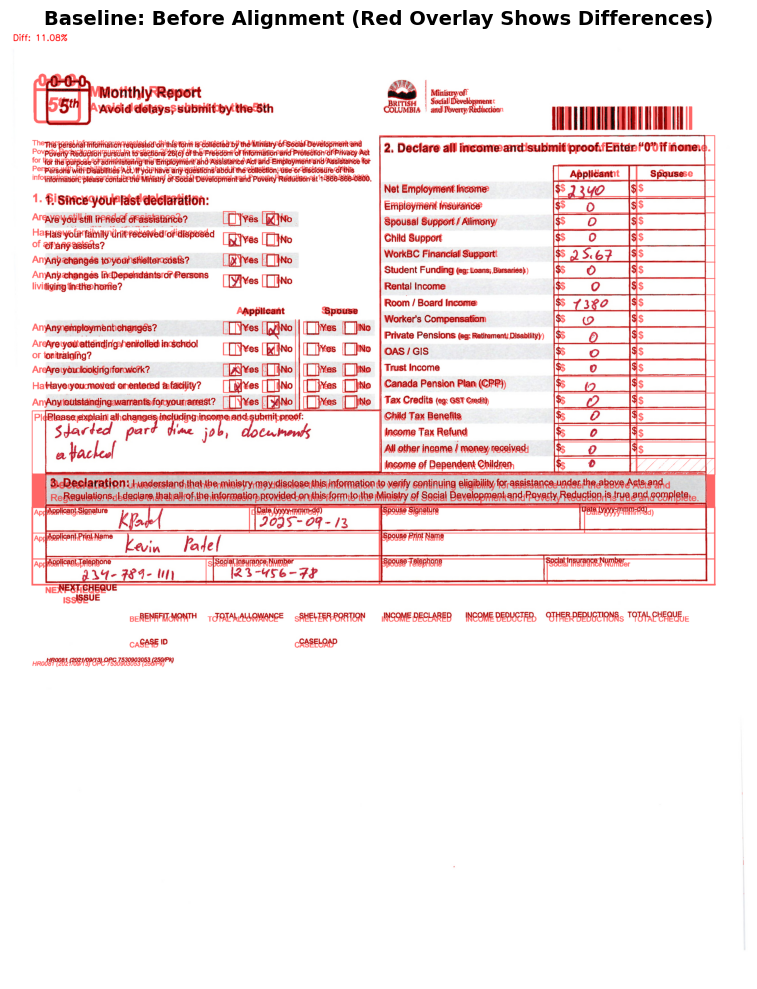

In [14]:
# Generate baseline red overlay diff - shows original misalignment
baseline_red_overlay = create_red_overlay_diff(
    template,
    input_img,
    threshold=30,
    alpha=0.6
)

# Display the baseline comparison
plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(baseline_red_overlay, cv2.COLOR_BGR2RGB))
plt.title('Baseline: Before Alignment (Red Overlay Shows Differences)', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## Default (fast ORB)
Uses ORB with balanced settings: reasonably strict matching, standard RANSAC threshold, and a minimum of 10 matches.
Good general-purpose choice for clean scans where you want speed and reliability without tuning.

[INFO] Using ORB detector (Oriented FAST and Rotated BRIEF)
       Pros: 24x faster than SIFT, free license, efficient
       Cons: Less robust to extreme rotations (>45°)

PHASE 1: GLOBAL FEATURE-BASED REGISTRATION

[STEP 1.1] Feature Detection and Matching
[INFO] Detected 5001 keypoints
[INFO] Detected 5000 keypoints
[INFO] Found 963/5001 good matches (19.3%)

[STEP 1.2] Homography Computation (RANSAC)
[INFO] RANSAC found 749/963 inliers (77.8%)
[INFO] Mean reprojection error: 1.66 pixels

[STEP 1.3] Image Warping and Registration
[INFO] Warped input image to template size: 2610x3348

----------------------------------------------------------------------
ALIGNMENT QUALITY METRICS:
----------------------------------------------------------------------
  ✓ Inlier ratio: 77.8% (target: >40%)
  ✓ Reprojection error: 1.66px (target: <5px)
  ✓ Total matches: 963
  ✓ Inlier matches: 749

  Quality Checks:
    ✓ Sufficient matches: PASS
    ✓ Good inlier ratio: PASS
    ✓ Low reprojection er

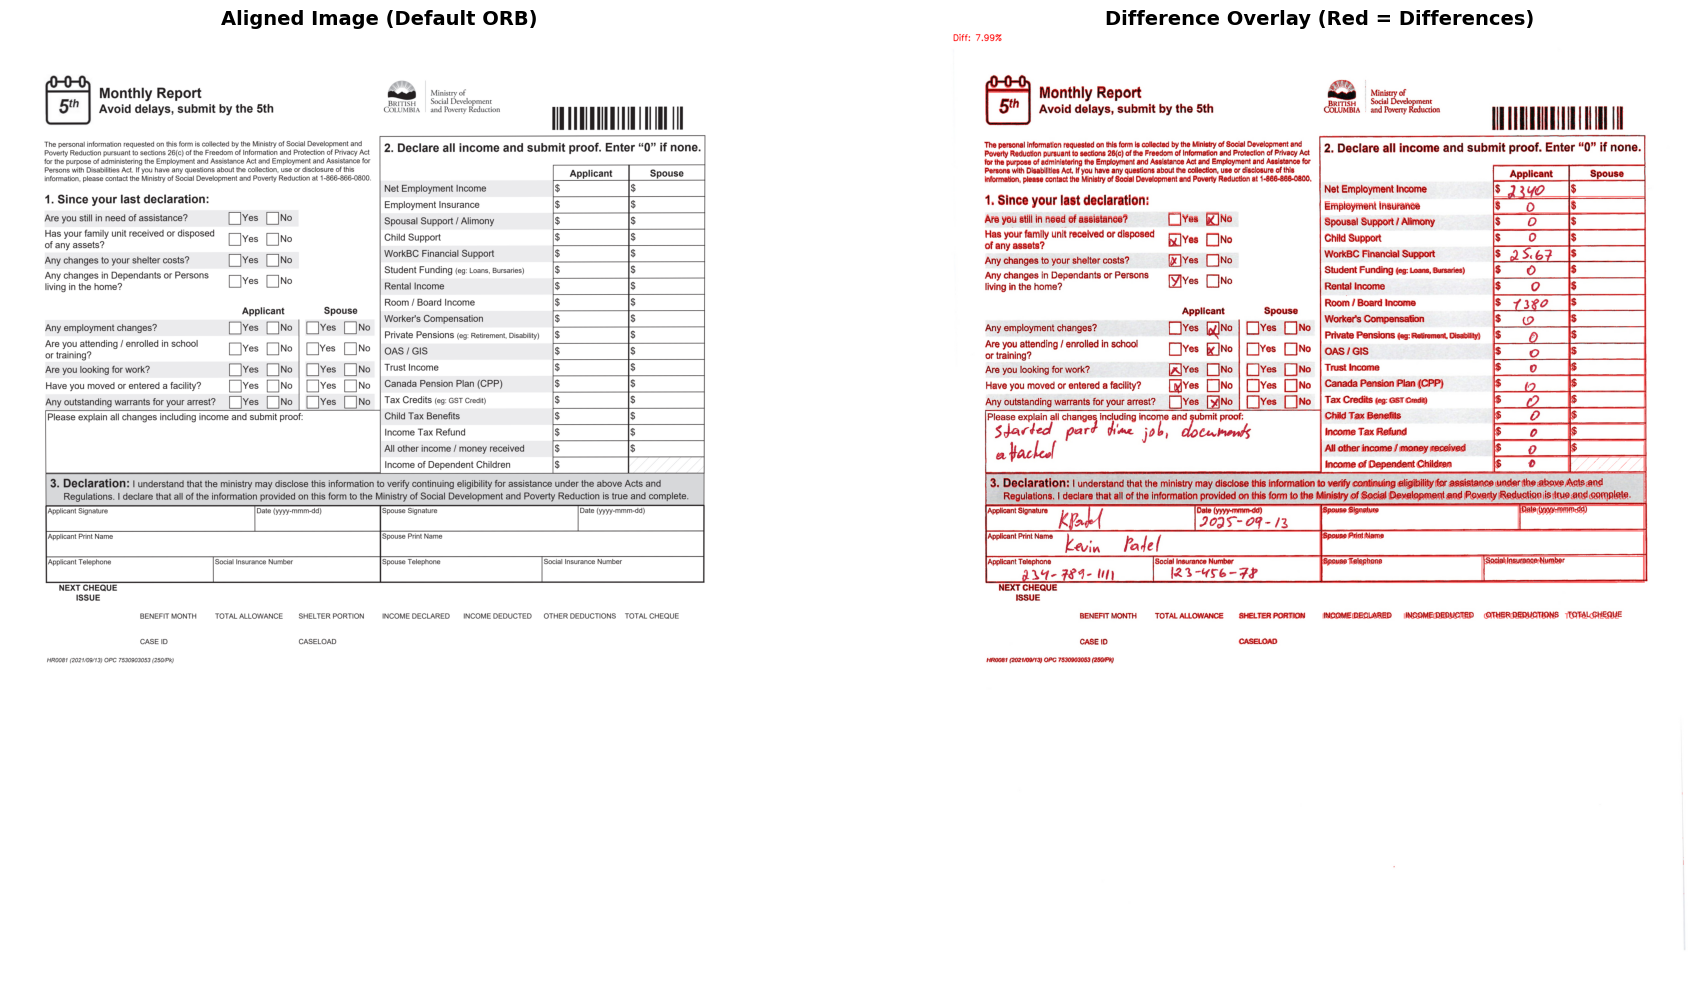

In [15]:
# Default (fast ORB) configuration
config = AlignmentConfig(
    feature_detector="ORB",
    max_features=5000,
    ratio_test_threshold=0.7,
    ransac_threshold=5.0,
    min_matches=10,
    verbose=True,
)

# Perform alignment
aligner = FeatureBasedAligner(config)
result_default = aligner.align(input_img, template)

print(f"\n[DEFAULT ORB] Alignment Results:")
print(f"  Reprojection Error: {result_default.reprojection_error:.2f}px")
print(f"  Inlier Ratio: {result_default.inlier_ratio:.1f}%")

# Save aligned image
success = cv2.imwrite(str(output_paths['default_orb']), result_default.aligned_image)
if success:
    print(f"✓ Saved aligned image to: {output_paths['default_orb']}")
else:
    print(f"✗ Failed to save aligned image")

# Create and save red overlay diff
red_overlay_default = create_red_overlay_diff(
    template,
    result_default.aligned_image,
    threshold=30,
    alpha=0.6
)
cv2.imwrite(str(diff_paths['default_orb']), red_overlay_default)
print(f"✓ Saved diff overlay to: {diff_paths['default_orb']}")

# Display results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].imshow(cv2.cvtColor(result_default.aligned_image, cv2.COLOR_BGR2RGB))
axes[0].set_title('Aligned Image (Default ORB)', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(red_overlay_default, cv2.COLOR_BGR2RGB))
axes[1].set_title('Difference Overlay (Red = Differences)', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## High Accuracy (SIFT)
Switches to SIFT with otherwise standard thresholds.
Better when documents may be rotated, slightly distorted, or you want the most accurate homography and can afford extra runtime.

[INFO] Using SIFT detector (Scale-Invariant Feature Transform)
       Pros: Highest accuracy, rotation/scale invariant
       Cons: Slower (~1-3 seconds per image)

PHASE 1: GLOBAL FEATURE-BASED REGISTRATION

[STEP 1.1] Feature Detection and Matching
[INFO] Detected 17829 keypoints
[INFO] Detected 35257 keypoints
[INFO] Found 3373/17829 good matches (18.9%)

[STEP 1.2] Homography Computation (RANSAC)
[INFO] RANSAC found 1936/3373 inliers (57.4%)
[INFO] Mean reprojection error: 1.56 pixels

[STEP 1.3] Image Warping and Registration
[INFO] Warped input image to template size: 2610x3348

----------------------------------------------------------------------
ALIGNMENT QUALITY METRICS:
----------------------------------------------------------------------
  ✓ Inlier ratio: 57.4% (target: >40%)
  ✓ Reprojection error: 1.56px (target: <5px)
  ✓ Total matches: 3373
  ✓ Inlier matches: 1936

  Quality Checks:
    ✓ Sufficient matches: PASS
    ✓ Good inlier ratio: PASS
    ✓ Low reprojection er

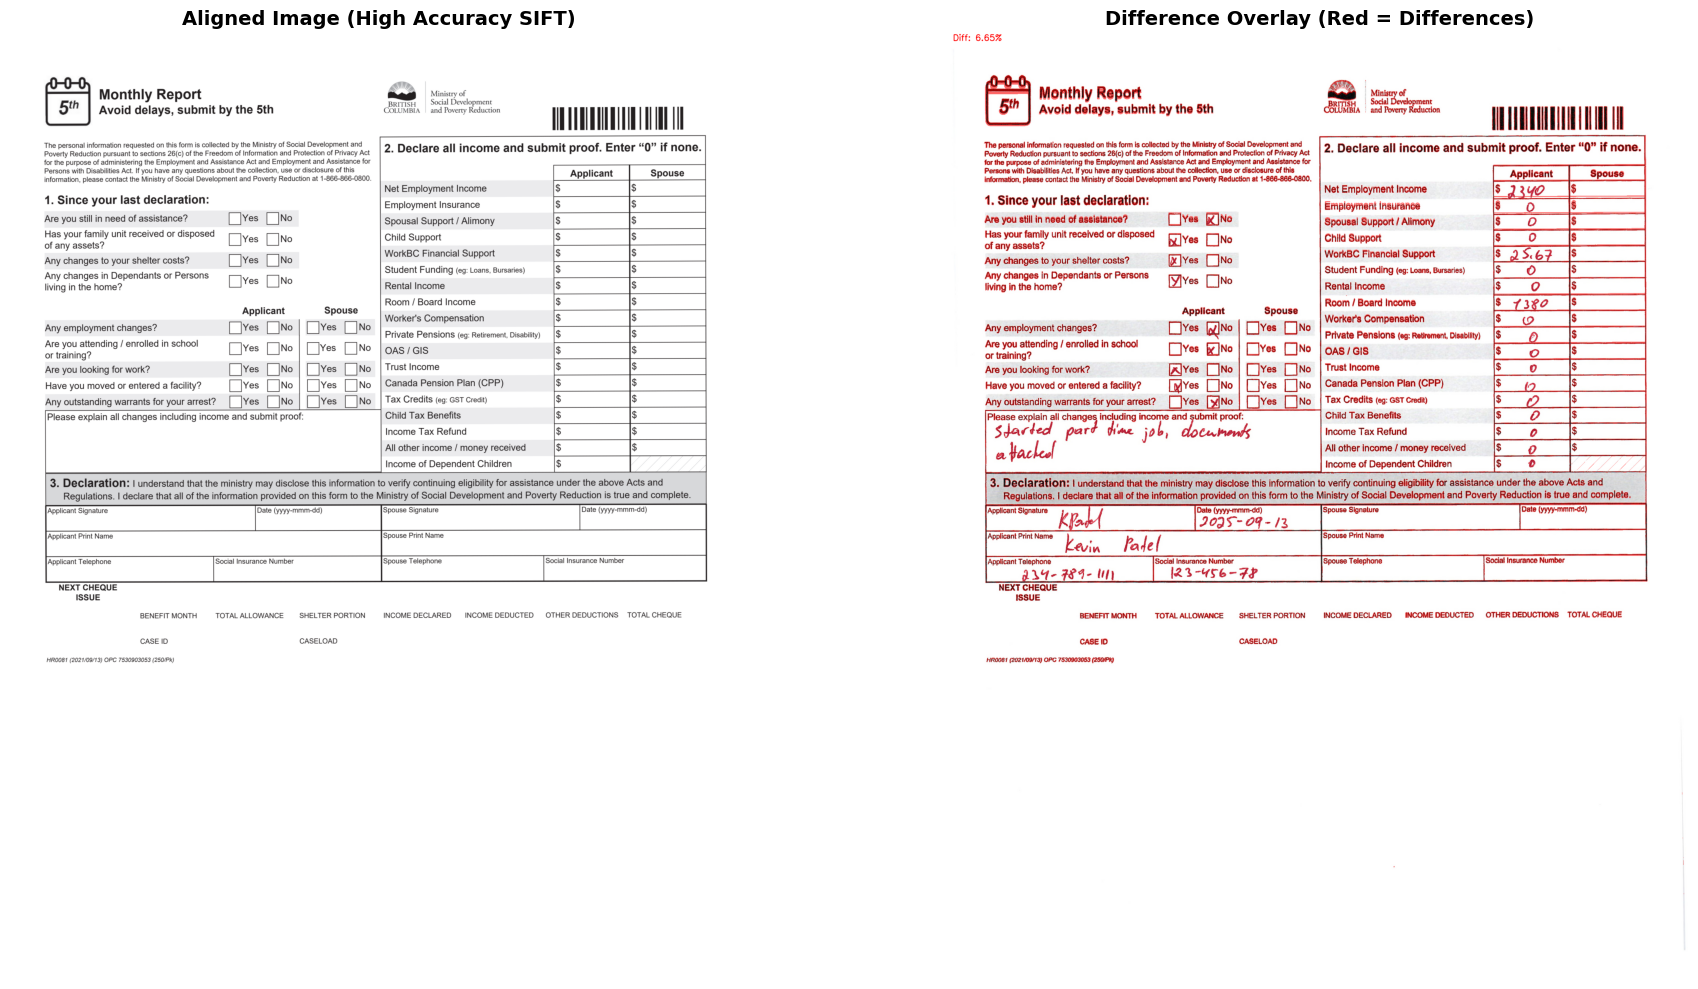

In [16]:
# High-accuracy SIFT configuration
config = AlignmentConfig(
    feature_detector="SIFT",      # More accurate, slower
    max_features=5000,
    ratio_test_threshold=0.7,     # Standard Lowe ratio
    ransac_threshold=5.0,         # Standard RANSAC threshold
    min_matches=10,
    verbose=True
)

# Perform alignment
aligner = FeatureBasedAligner(config)
result_accurate = aligner.align(input_img, template)

print(f"\n[ACCURATE SIFT] Alignment Results:")
print(f"  Reprojection Error: {result_accurate.reprojection_error:.2f}px")
print(f"  Inlier Ratio: {result_accurate.inlier_ratio:.1f}%")

# Save aligned image
success = cv2.imwrite(str(output_paths['accurate_sift']), result_accurate.aligned_image)
if success:
    print(f"✓ Saved aligned image to: {output_paths['accurate_sift']}")
else:
    print(f"✗ Failed to save aligned image")

# Create and save red overlay diff
red_overlay_accurate = create_red_overlay_diff(
    template,
    result_accurate.aligned_image,
    threshold=30,
    alpha=0.6
)
cv2.imwrite(str(diff_paths['accurate_sift']), red_overlay_accurate)
print(f"✓ Saved diff overlay to: {diff_paths['accurate_sift']}")

# Display results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].imshow(cv2.cvtColor(result_accurate.aligned_image, cv2.COLOR_BGR2RGB))
axes[0].set_title('Aligned Image (High Accuracy SIFT)', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(red_overlay_accurate, cv2.COLOR_BGR2RGB))
axes[1].set_title('Difference Overlay (Red = Differences)', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Difficult Documents (relaxed, SIFT)
Still uses SIFT but relaxes the matching and RANSAC thresholds, and allows fewer matches while looking for more features.
Intended for low-contrast, noisy, partially visible, or otherwise "hard" documents where default settings fail due to too few inliers.

[INFO] Using SIFT detector (Scale-Invariant Feature Transform)
       Pros: Highest accuracy, rotation/scale invariant
       Cons: Slower (~1-3 seconds per image)

PHASE 1: GLOBAL FEATURE-BASED REGISTRATION

[STEP 1.1] Feature Detection and Matching
[INFO] Detected 17829 keypoints
[INFO] Detected 35257 keypoints
[INFO] Found 5569/17829 good matches (31.2%)

[STEP 1.2] Homography Computation (RANSAC)
[INFO] RANSAC found 2494/5569 inliers (44.8%)
[INFO] Mean reprojection error: 1.70 pixels

[STEP 1.3] Image Warping and Registration
[INFO] Warped input image to template size: 2610x3348

----------------------------------------------------------------------
ALIGNMENT QUALITY METRICS:
----------------------------------------------------------------------
  ✓ Inlier ratio: 44.8% (target: >40%)
  ✓ Reprojection error: 1.70px (target: <5px)
  ✓ Total matches: 5569
  ✓ Inlier matches: 2494

  Quality Checks:
    ✓ Sufficient matches: PASS
    ✓ Good inlier ratio: PASS
    ✓ Low reprojection er

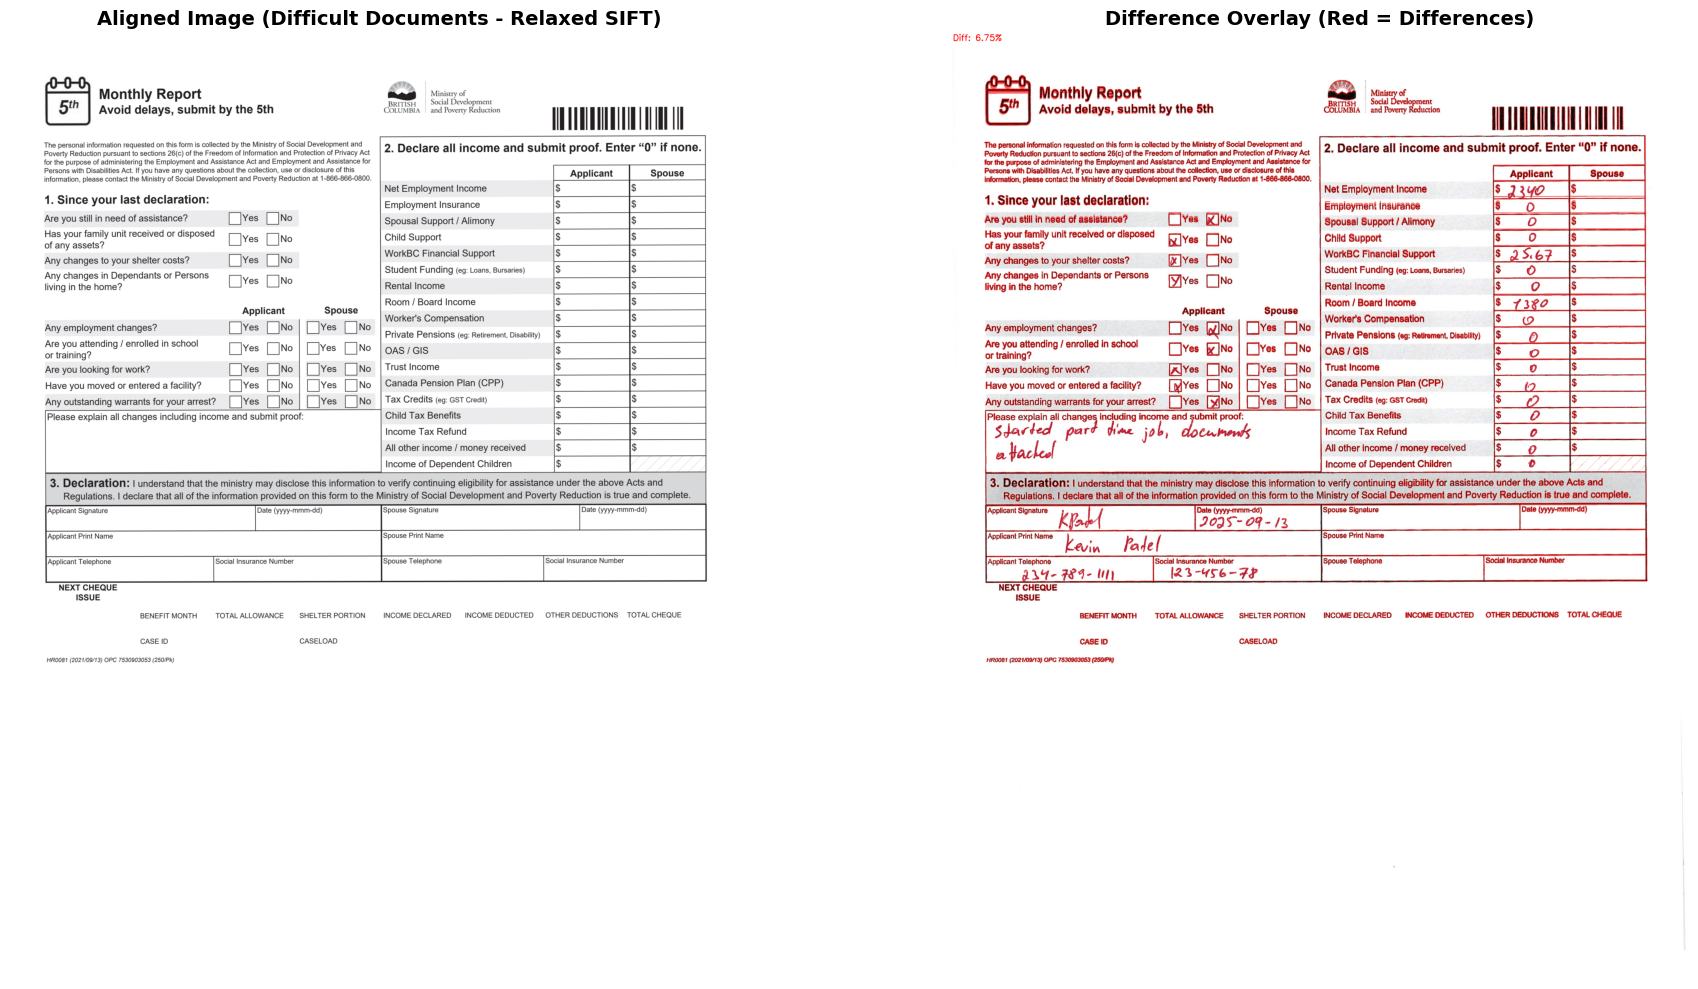

In [17]:
# Relaxed config for low-contrast / noisy / partially visible docs
config = AlignmentConfig(
    feature_detector="SIFT",
    max_features=8000,            # Look for more features
    ratio_test_threshold=0.8,     # More lenient matching
    ransac_threshold=7.0,         # More tolerant RANSAC
    min_matches=8,               # Allow fewer matches
    verbose=True
)

# Perform alignment
aligner = FeatureBasedAligner(config)
result_difficult = aligner.align(input_img, template)

print(f"\n[DIFFICULT] Alignment Results:")
print(f"  Reprojection Error: {result_difficult.reprojection_error:.2f}px")
print(f"  Inlier Ratio: {result_difficult.inlier_ratio:.1f}%")

# Save aligned image
success = cv2.imwrite(str(output_paths['difficult']), result_difficult.aligned_image)
if success:
    print(f"✓ Saved aligned image to: {output_paths['difficult']}")
else:
    print(f"✗ Failed to save aligned image")

# Create and save red overlay diff
red_overlay_difficult = create_red_overlay_diff(
    template,
    result_difficult.aligned_image,
    threshold=30,
    alpha=0.6
)
cv2.imwrite(str(diff_paths['difficult']), red_overlay_difficult)
print(f"✓ Saved diff overlay to: {diff_paths['difficult']}")

# Display results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].imshow(cv2.cvtColor(result_difficult.aligned_image, cv2.COLOR_BGR2RGB))
axes[0].set_title('Aligned Image (Difficult Documents - Relaxed SIFT)', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(red_overlay_difficult, cv2.COLOR_BGR2RGB))
axes[1].set_title('Difference Overlay (Red = Differences)', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Strict Quality Control
Uses SIFT with stricter ratio test, tighter RANSAC threshold, and higher minimum matches.
Designed for production quality gates where you only accept very precise alignments and are okay with rejecting marginal cases.

[INFO] Using SIFT detector (Scale-Invariant Feature Transform)
       Pros: Highest accuracy, rotation/scale invariant
       Cons: Slower (~1-3 seconds per image)

PHASE 1: GLOBAL FEATURE-BASED REGISTRATION

[STEP 1.1] Feature Detection and Matching
[INFO] Detected 17829 keypoints
[INFO] Detected 35257 keypoints
[INFO] Found 2685/17829 good matches (15.1%)

[STEP 1.2] Homography Computation (RANSAC)
[INFO] RANSAC found 1550/2685 inliers (57.7%)
[INFO] Mean reprojection error: 1.59 pixels

[STEP 1.3] Image Warping and Registration
[INFO] Warped input image to template size: 2610x3348

----------------------------------------------------------------------
ALIGNMENT QUALITY METRICS:
----------------------------------------------------------------------
  ✓ Inlier ratio: 57.7% (target: >40%)
  ✓ Reprojection error: 1.59px (target: <5px)
  ✓ Total matches: 2685
  ✓ Inlier matches: 1550

  Quality Checks:
    ✓ Sufficient matches: PASS
    ✓ Good inlier ratio: PASS
    ✓ Low reprojection er

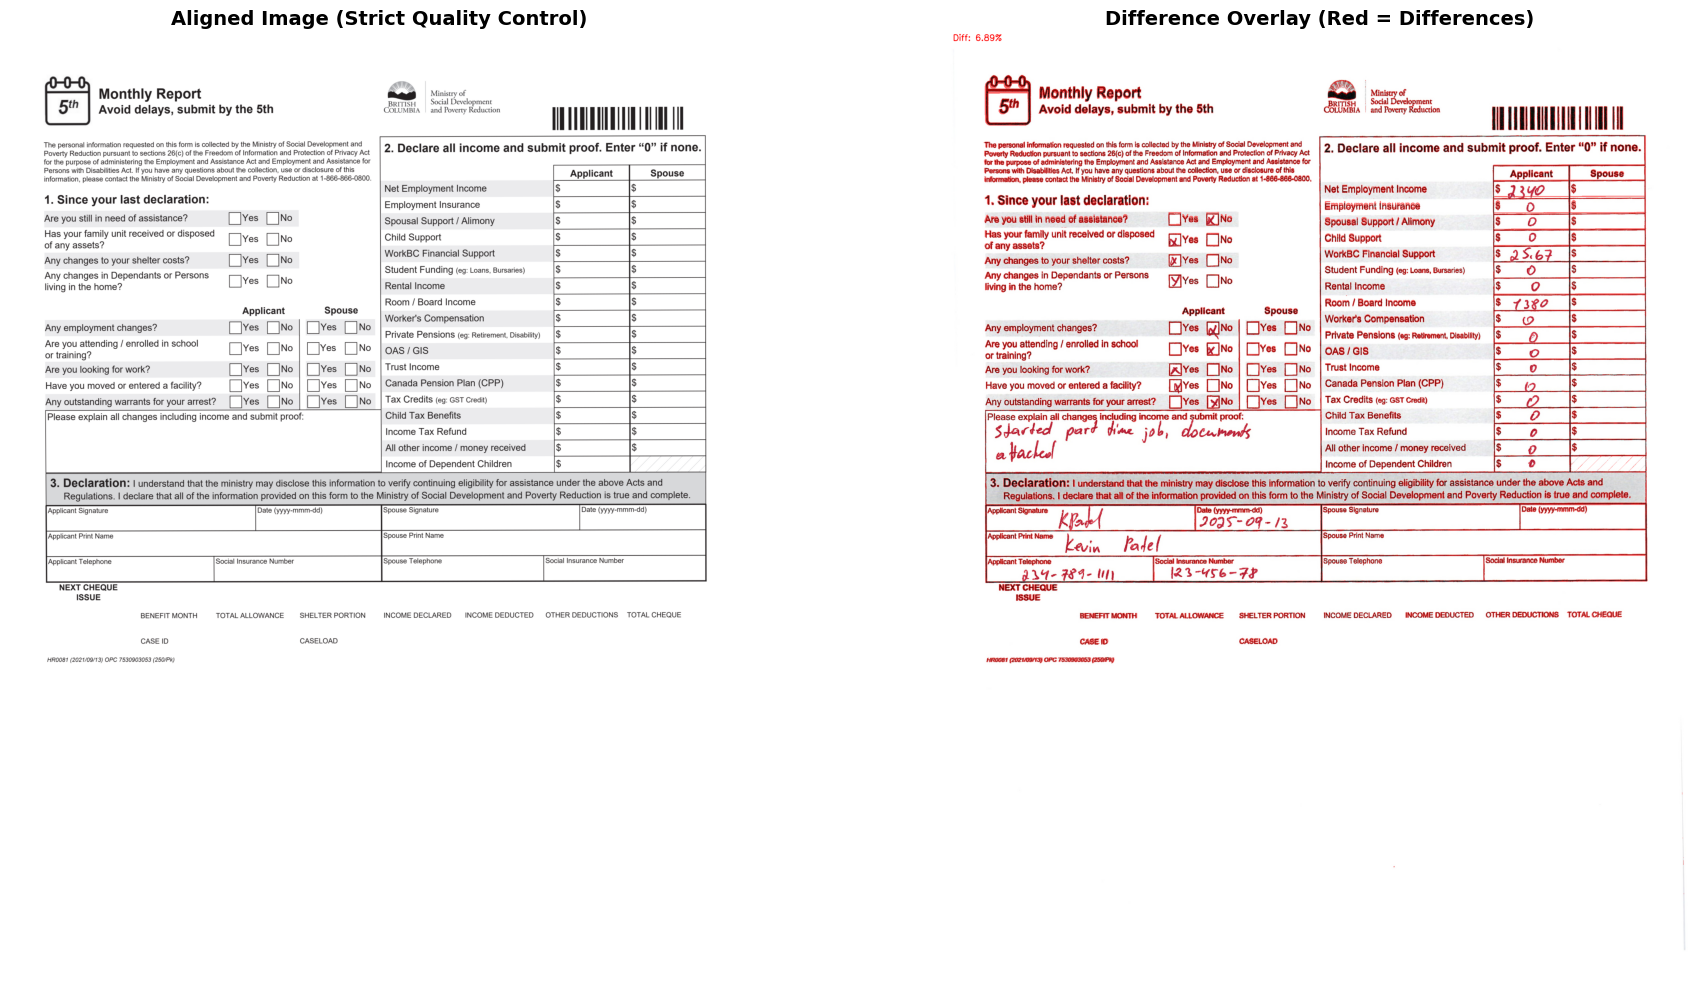

In [18]:
# Strict configuration for QC (reject marginal alignments)
config = AlignmentConfig(
    feature_detector="SIFT",
    max_features=6000,
    ratio_test_threshold=0.65,    # Stricter Lowe ratio
    ransac_threshold=3.0,         # Tight inlier threshold
    min_matches=20,              # Require more matches
    verbose=True
)

# Perform alignment
aligner = FeatureBasedAligner(config)
result_strict = aligner.align(input_img, template)

print(f"\n[STRICT QC] Alignment Results:")
print(f"  Reprojection Error: {result_strict.reprojection_error:.2f}px")
print(f"  Inlier Ratio: {result_strict.inlier_ratio:.1f}%")

# Optional simple pass/fail:
ok = (result_strict.inlier_ratio > 50 and result_strict.reprojection_error < 3)
print(f"[STRICT QC] PASS: {ok}")

# Save aligned image
success = cv2.imwrite(str(output_paths['strict_qc']), result_strict.aligned_image)
if success:
    print(f"✓ Saved aligned image to: {output_paths['strict_qc']}")
else:
    print(f"✗ Failed to save aligned image")

# Create and save red overlay diff
red_overlay_strict = create_red_overlay_diff(
    template,
    result_strict.aligned_image,
    threshold=30,
    alpha=0.6
)
cv2.imwrite(str(diff_paths['strict_qc']), red_overlay_strict)
print(f"✓ Saved diff overlay to: {diff_paths['strict_qc']}")

# Display results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].imshow(cv2.cvtColor(result_strict.aligned_image, cv2.COLOR_BGR2RGB))
axes[0].set_title('Aligned Image (Strict Quality Control)', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(red_overlay_strict, cv2.COLOR_BGR2RGB))
axes[1].set_title('Difference Overlay (Red = Differences)', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Summary

All alignment results have been saved to the templates folder:

**Aligned Images:**
- `hr0081_aligned_default_orb.png` - Default (fast ORB)
- `hr0081_aligned_accurate_sift.png` - High Accuracy (SIFT)
- `hr0081_aligned_difficult.png` - Difficult Documents (relaxed SIFT)
- `hr0081_aligned_strict_qc.png` - Strict Quality Control (SIFT)

**Difference Overlays:**
- `hr0081_diff_default_orb.png` - Default (fast ORB)
- `hr0081_diff_accurate_sift.png` - High Accuracy (SIFT)
- `hr0081_diff_difficult.png` - Difficult Documents (relaxed SIFT)
- `hr0081_diff_strict_qc.png` - Strict Quality Control (SIFT)